In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Carregar o dataset validado pelo Protocolo de Manchester
df = pd.read_csv('assets/dataset_triagem.csv')
display(df.head())

,frase,situacao
0,dor no peito em aperto que começou de repente ...,alto risco
1,acordei com falta de ar severa e sinto que vou...,alto risco
2,tive um desmaio repentino e agora meu peito es...,alto risco
3,dor torácica intensa acompanhada de suor frio ...,alto risco
4,"minha pressão está 22 por 14, estou com dor de...",alto risco


In [2]:
# Transformação Matemática (TF-IDF)
# Aplicar o TF-IDF para converter texto em vetores numéricos
vectorizer = TfidfVectorizer(lowercase=True)
X_tfidf = vectorizer.fit_transform(df['frase'])
y = df['situacao']

print(f"Dimensões da matriz TF-IDF: {X_tfidf.shape}")
print(f"Total de termos (features) extraídos: {len(vectorizer.get_feature_names_out())}")

Dimensões da matriz TF-IDF: (30, 173)
Total de termos (features) extraídos: 173


In [3]:
# Divisão e Treinamento do Modelo
# Divisão estratificada para garantir o mesmo rácio de alto/baixo risco
X_train, X_test, y_train, y_test = train_test_split(X_tfidf, y, test_size=0.3, random_state=42, stratify=y)

# Escolha do modelo: Logistic Regression lida muito bem com dados textuais esparsos
model = LogisticRegression(random_state=42)
model.fit(X_train, y_train)

print("Modelo de classificação treinado com sucesso!")

Modelo de classificação treinado com sucesso!


Acurácia Global do Modelo: 44.44%

Relatório Analítico de Classificação:
              precision    recall  f1-score   support

  alto risco       0.00      0.00      0.00         5
 baixo risco       0.44      1.00      0.62         4

    accuracy                           0.44         9
   macro avg       0.22      0.50      0.31         9
weighted avg       0.20      0.44      0.27         9



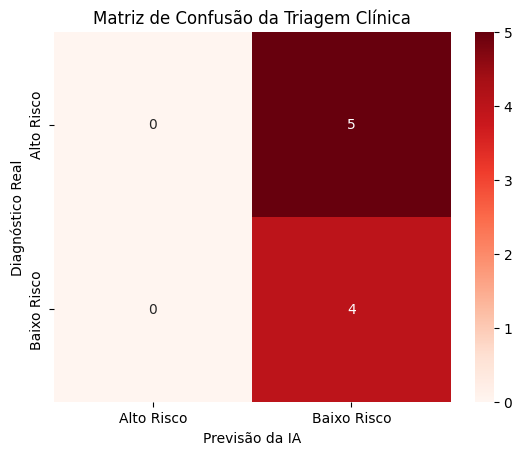

In [5]:
# Avaliação do Desempenho
y_pred = model.predict(X_test)

print(f"Acurácia Global do Modelo: {accuracy_score(y_test, y_pred) * 100:.2f}%\n")
print("Relatório Analítico de Classificação:")
print(classification_report(y_test, y_pred, zero_division=0))

# Matriz de Confusão visual
cm = confusion_matrix(y_test, y_pred, labels=["alto risco", "baixo risco"])
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', 
            xticklabels=["Alto Risco", "Baixo Risco"], 
            yticklabels=["Alto Risco", "Baixo Risco"])
plt.ylabel('Diagnóstico Real')
plt.xlabel('Previsão da IA')
plt.title('Matriz de Confusão da Triagem Clínica')
plt.show()